### Linear Regression ###


In [20]:
# Import pandas and numpy
import pandas as pd
import numpy as np

# Scaler
from sklearn.preprocessing import StandardScaler

# Import warnings module and set to display all warnings
import warnings
warnings.filterwarnings("ignore")

# Plotly
import plotly.express as px

# Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import train_test_split

# Import LinearRegression from scikit-learn
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm


### Dataset Importing and Preparation

In [21]:
# Load the CSV file
df = pd.read_csv("House prises df_train.csv")

In [22]:
# Display the first few rows of the dataset
df.head()

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
0,2014-05-15,312000.0,2,2,True,138.42547,False,False,False,2,True,False,5,1
1,2014-11-14,310000.0,2,2,False,105.90942,False,False,False,1,True,False,11,3
2,2014-12-24,320000.0,2,2,False,117.98681,False,True,False,1,False,True,12,2
3,2015-02-22,264500.0,2,3,False,151.43189,False,False,False,2,True,True,2,1
4,2015-01-06,700000.0,3,2,True,341.88304,False,False,False,3,False,False,1,4


In [23]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13603 entries, 0 to 13602
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               13603 non-null  object 
 1   price              13603 non-null  float64
 2   bedrooms           13603 non-null  int64  
 3   grade              13603 non-null  int64  
 4   has_basement       13603 non-null  bool   
 5   living_in_m2       13603 non-null  float64
 6   renovated          13603 non-null  bool   
 7   nice_view          13603 non-null  bool   
 8   perfect_condition  13603 non-null  bool   
 9   real_bathrooms     13603 non-null  int64  
 10  has_lavatory       13603 non-null  bool   
 11  single_floor       13603 non-null  bool   
 12  month              13603 non-null  int64  
 13  quartile_zone      13603 non-null  int64  
dtypes: bool(6), float64(2), int64(5), object(1)
memory usage: 930.0+ KB


In [24]:
# Checking for null values
df.isnull().any()

date                 False
price                False
bedrooms             False
grade                False
has_basement         False
living_in_m2         False
renovated            False
nice_view            False
perfect_condition    False
real_bathrooms       False
has_lavatory         False
single_floor         False
month                False
quartile_zone        False
dtype: bool

In [25]:
# Reset the index
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1
df.head()

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
1,2014-05-15,312000.0,2,2,True,138.42547,False,False,False,2,True,False,5,1
2,2014-11-14,310000.0,2,2,False,105.90942,False,False,False,1,True,False,11,3
3,2014-12-24,320000.0,2,2,False,117.98681,False,True,False,1,False,True,12,2
4,2015-02-22,264500.0,2,3,False,151.43189,False,False,False,2,True,True,2,1
5,2015-01-06,700000.0,3,2,True,341.88304,False,False,False,3,False,False,1,4


### Dataset Exploration

In [26]:
# N unique values in dataset
df=df.drop(columns=['date'])
df.nunique()

price                2770
bedrooms                3
grade                   5
has_basement            2
living_in_m2          670
renovated               2
nice_view               2
perfect_condition       2
real_bathrooms          3
has_lavatory            2
single_floor            2
month                  12
quartile_zone           4
dtype: int64

In [27]:
# Checking unique values
columns_with_less_than_20_unique = [col for col in df.columns if df[col].nunique() < 20]
unique_values = {col: df[col].unique().tolist() for col in columns_with_less_than_20_unique}
unique_values

{'bedrooms': [2, 3, 1],
 'grade': [2, 3, 1, 5, 4],
 'has_basement': [True, False],
 'renovated': [False, True],
 'nice_view': [False, True],
 'perfect_condition': [False, True],
 'real_bathrooms': [2, 1, 3],
 'has_lavatory': [True, False],
 'single_floor': [False, True],
 'month': [5, 11, 12, 2, 1, 3, 6, 10, 7, 9, 8, 4],
 'quartile_zone': [1, 3, 2, 4]}

In [28]:
# Loop through each column and create a square pie chart for unique values
for col in columns_with_less_than_20_unique:
    # Count occurrences of each unique value in the column
    value_counts = df[col].value_counts()

    # Create a square pie chart
    fig = px.pie(
        names=value_counts.index,
        values=value_counts.values,
        title=f"Distribution of Unique Values in '{col}' Column",
        width=600,  # Set the width to 600 pixels
        height=600  # Set the height to 600 pixels to make it square
    )

    # Display the chart
    fig.show()


In [29]:
import plotly.express as px

# Correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto=True,  # Shows correlation values on the heatmap
    color_continuous_scale='RdBu',  # Color scheme
    zmin=-1, zmax=1,  # Sets color range from -1 to 1 for correlation values
    width=1000,
    height=1000
)
fig.update_layout(title={'text':"Correlation Heatmap", 'x':0.5, 'xanchor':'center' })
fig.show()


In [30]:
# Create a histogram to visualize the distribution
fig = px.histogram(df, x='price', nbins=30, title='Distribution of House Prices',
                   labels={'House Price': 'Price ($)'}, opacity=0.75)
fig.show()

In [31]:
# Create a histogram to visualize the distribution
fig = px.histogram(df, x='living_in_m2', nbins=30, title='Distribution of Living Area Squared Meter',
                   labels={'House Price': 'Price ($)'}, opacity=0.75)

fig.show()

### Feature Selection 

In [32]:
# Set target variable
target_variable='price'

# Calculate correlation matrix
Correlation_matrix=df.corr()

# Get correlation with target variable
Correlation_with_target_variable=Correlation_matrix[target_variable].drop(target_variable)

# Significant features
Significant_features=Correlation_with_target_variable[Correlation_with_target_variable.abs()>0.25]

Significant_features

bedrooms          0.293798
grade             0.622948
living_in_m2      0.613254
real_bathrooms    0.389409
single_floor     -0.287796
quartile_zone     0.670145
Name: price, dtype: float64

In [33]:
# Create new dataframe
# Create a new DataFrame with only the significant features and the target variable
Significant_df = df[Significant_features.index.union([target_variable])]
Significant_df.head()

,bedrooms,grade,living_in_m2,price,quartile_zone,real_bathrooms,single_floor
1,2,2,138.42547,312000.0,1,2,False
2,2,2,105.90942,310000.0,3,1,False
3,2,2,117.98681,320000.0,2,1,True
4,2,3,151.43189,264500.0,1,2,True
5,3,2,341.88304,700000.0,4,3,False


In [34]:
Significant_features.index

Index(['bedrooms', 'grade', 'living_in_m2', 'real_bathrooms', 'single_floor',
       'quartile_zone'],
      dtype='object')

In [35]:
# Columns to be converted to dummy variables
columns_to_convert = ['bedrooms', 'grade', 'real_bathrooms', 'single_floor', 'quartile_zone']

# Convert specified columns to dummy variables while excluding 'living_in_m2'
Significant_df_with_dummies = pd.get_dummies(Significant_df, columns=columns_to_convert, drop_first=True)

# Scaling living area
# Initialize the scaler
scaler = StandardScaler()

# Scale only the 'living_in_m2' column and add the result as a new column
Significant_df_with_dummies['living_in_m2_scaled'] = scaler.fit_transform(Significant_df_with_dummies[['living_in_m2']])

# Droping original living area column
Significant_df_with_dummies.drop(columns=['living_in_m2'], inplace= True)

# Drop rows with NaN values
Significant_df_with_dummies.dropna(inplace=True)

print("DataFrame with dummy variables and scaled 'living_in_m2':")
Significant_df_with_dummies.head()

DataFrame with dummy variables and scaled 'living_in_m2':


,price,bedrooms_2,bedrooms_3,grade_2,grade_3,grade_4,grade_5,real_bathrooms_2,real_bathrooms_3,single_floor_True,quartile_zone_2,quartile_zone_3,quartile_zone_4,living_in_m2_scaled
1,312000.0,True,False,True,False,False,False,True,False,False,False,False,False,-0.637869
2,310000.0,True,False,True,False,False,False,False,False,False,False,True,False,-1.116647
3,320000.0,True,False,True,False,False,False,False,False,True,True,False,False,-0.938815
4,264500.0,True,False,False,True,False,False,True,False,True,False,False,False,-0.446358
5,700000.0,False,True,True,False,False,False,False,True,False,False,False,True,2.357911


### ML Model

In [36]:
# Split dataset into train and test

# Define your features (X) and target variable (y)
X = Significant_df_with_dummies.drop(columns=['price'])
y = Significant_df_with_dummies['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Linear Regression Model
LR = LinearRegression()

# Train Linear Regression model
LR_Model=LR.fit(X_train, y_train)

# Predict on X_test using Linear Regression
y_pred = LR_Model.predict(X_test)

# Model Evaluation for Linear Regression
LR_train_score = LR_Model.score(X_train, y_train)
LR_test_score = LR_Model.score(X_test, y_test)
MSE = mean_squared_error(y_test, y_pred)
R_squared = r2_score(y_test, y_pred)

# Print evaluation metrics for Linear Regression
print('\nLinear Regression:')
print('Training R_squared: ', LR_train_score)
print('Testing R_squared: ', LR_test_score)
print('MSE: ', MSE)
print('R_squared: ', R_squared)


Linear Regression:
Training R_squared:  0.7232660430999838
Testing R_squared:  0.716053116950818
MSE:  11804228110.121382
R_squared:  0.716053116950818


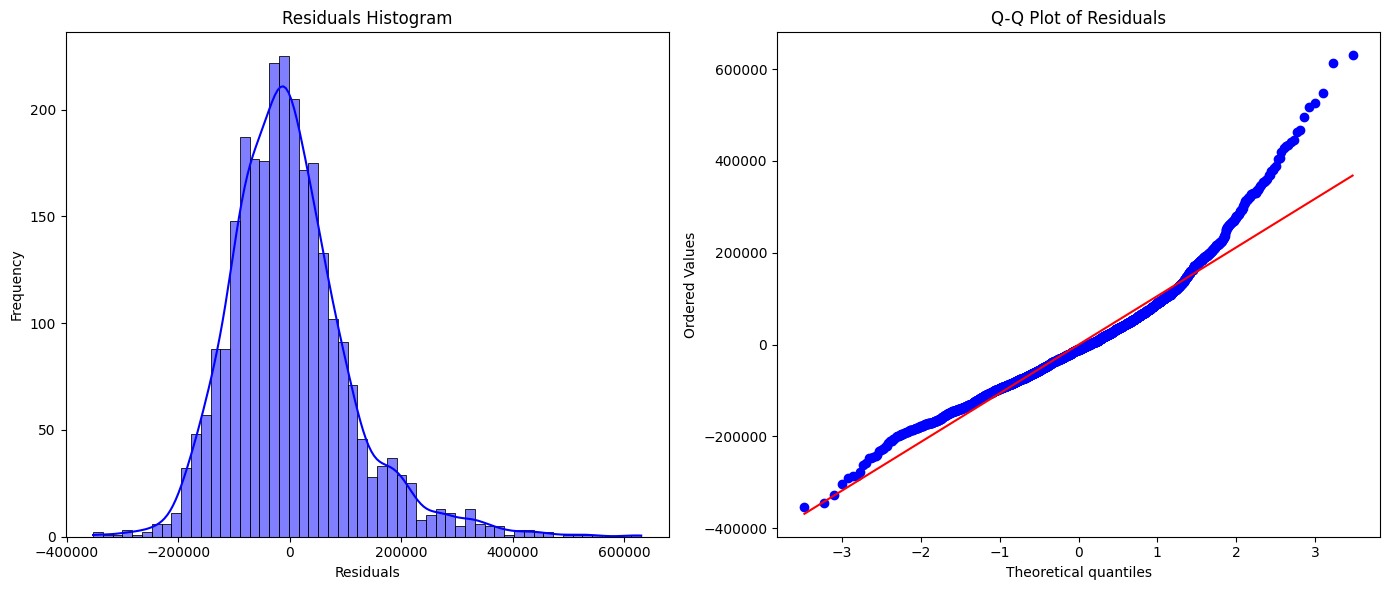

In [38]:
from scipy.stats import probplot

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals distribution
plt.figure(figsize=(14, 6))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='blue')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Q-Q plot for normality check
plt.subplot(1, 2, 2)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


In [39]:

# Calculate residuals
residuals = y_test - y_pred

# Histogram of residuals
fig1 = px.histogram(residuals, nbins=40, title='Residuals Histogram')
fig1.update_layout(xaxis_title='Residuals', yaxis_title='Frequency')
fig1.show()


In [40]:
# Pandas can represent boolean columns as bool types, and they are displayed as True and False. This is a valid representation, but for regression modeling, 
# you typically want to convert these to integers (0 and 1) to ensure compatibility with certain libraries, like statsmodels or machine learning models from scikit-learn.

# Convert boolean columns to integers (0 and 1)
bool_columns = Significant_df_with_dummies.select_dtypes(include=[bool]).columns
Significant_df_with_dummies[bool_columns] = Significant_df_with_dummies[bool_columns].astype(int)

# Define features (X) and target variable (y)
X = Significant_df_with_dummies.drop(columns=['price'])  # Replace 'price' with your actual target variable name
y = Significant_df_with_dummies['price']  # Ensure this is your target variable

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Get the summary to see coefficients and p-values
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     2714.
Date:                Thu, 11 Sep 2025   Prob (F-statistic):               0.00
Time:                        11:35:06   Log-Likelihood:            -1.7712e+05
No. Observations:               13603   AIC:                         3.543e+05
Df Residuals:                   13589   BIC:                         3.544e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.853e+05   4

### Regularization

In [41]:
# Ridge Regression Model
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Ridge Model Evaluation
ridge_train_score = ridge_model.score(X_train, y_train)
ridge_test_score = ridge_model.score(X_test, y_test)
ridge_r_squared = r2_score(y_test, ridge_pred)

print('Ridge Regression:')
print('Training R_squared: ', ridge_train_score)
print('Testing R_squared: ', ridge_test_score)
print('Testing R_squared (using r2_score): ', ridge_r_squared)

# Print Ridge coefficients and intercept
print('Ridge Coefficients:', ridge_model.coef_)
print('Ridge Intercept:', ridge_model.intercept_)

# Lasso Regression Model
lasso_model = Lasso()
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# Lasso Model Evaluation
lasso_train_score = lasso_model.score(X_train, y_train)
lasso_test_score = lasso_model.score(X_test, y_test)
lasso_r_squared = r2_score(y_test, lasso_pred)

print('\nLasso Regression:')
print('Training R_squared: ', lasso_train_score)
print('Testing R_squared: ', lasso_test_score)
print('Testing R_squared (using r2_score): ', lasso_r_squared)

# Print Lasso coefficients and intercept
print('Lasso Coefficients:', lasso_model.coef_)
print('Lasso Intercept:', lasso_model.intercept_)

Ridge Regression:
Training R_squared:  0.7232649665916927
Testing R_squared:  0.7160537143649518
Testing R_squared (using r2_score):  0.7160537143649518
Ridge Coefficients: [ -5430.62576152  -3518.33724458  23567.97735342  62793.49433881
 133264.4126393  177823.51530946 -22424.22756385   8042.08370244
   2818.23734442 101246.40989814 235350.71220284 295553.22703841
  79861.69215517]
Ridge Intercept: 286177.7559381217

Lasso Regression:
Training R_squared:  0.7232660347010103
Testing R_squared:  0.7160525096054042
Testing R_squared (using r2_score):  0.7160525096054042
Lasso Coefficients: [ -5422.51196998  -3455.2316443   23948.87216339  63283.54673442
 133935.93101252 178864.89910678 -22488.43065589   7952.01629928
   2886.11132572 101490.54233741 235617.47947588 295816.56335659
  79733.39868897]
Lasso Intercept: 285531.86340885336


### Polynomial Regression

In [42]:
# Create polynomial features fo degree of 2
Poly_Features=PolynomialFeatures(degree=2)
X_train_poly=Poly_Features.fit_transform(X_train)
X_test_poly=Poly_Features.fit_transform(X_test)

# Linear Model
LR=LinearRegression()

# Model
Model=LR.fit(X_train_poly, y_train)

# Predict
Y_pred_testing=Model.predict(X_test_poly)

Y_pred_training=Model.predict(X_train_poly)

# Model Evaluation
print('Testing R_squared: ', r2_score(Y_pred_testing, y_test))
print('Training R_squared: ', r2_score(Y_pred_training, y_train))

Testing R_squared:  0.6327140098026013
Training R_squared:  0.6467938363229404


### Linear vs Polynomial

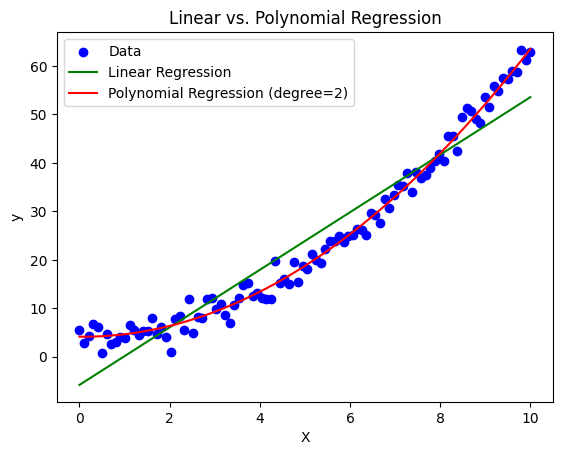

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 0.5 * X**2 + X + 2 + np.random.normal(0, 2, X.shape)  # Quadratic relationship with some noise

# Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X, y)
y_linear_pred = linear_model.predict(X)

# Polynomial Regression Model
degree = 2  # You can increase this to see higher-order polynomials
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# Plotting the results
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_linear_pred, color='green', label='Linear Regression')
plt.plot(X, y_poly_pred, color='red', label=f'Polynomial Regression (degree={degree})')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear vs. Polynomial Regression')
plt.show()
